# Visualizing Multi-Head Attention in BERT — *BertViz* Demo

### Hands-on companion to the *Self-Attention &amp; Multi-Head Attention* module

In the theory module we claimed that a Transformer reads a sentence from **several angles at once**:
different attention **heads** learn to capture **different relationships** between words.

This notebook lets you **see that happening inside a real, pre-trained BERT model**, live, in front of your class.

We use a classic ambiguous "tough-construction" sentence:

> **"The chicken is ready to eat."**

This sentence has two valid readings:
1. **Agent reading:** the chicken is hungry and ready to eat *something* &nbsp;→&nbsp; expect a head where **`chicken`** attends strongly **to** **`eat`**
2. **Patient reading:** the chicken is cooked and ready for someone to eat *it* &nbsp;→&nbsp; expect a head where **`eat`** attends strongly back **to** **`chicken`**

Our goal: open up BERT's 12 layers × 12 heads and **find the heads that capture each interpretation** — this time
by explicitly picking out **two (layer, head) pairs**, one per perspective, and comparing them side by side.

---
**What you will produce in this notebook**
| View | What it shows | Best for |
|------|---------------|----------|
| **Head View** | All heads of one layer, as connecting lines | Exploring head-by-head interactively |
| **Model View** | Every layer × every head in one grid | The big picture of the whole model |
| **Neuron View** | The actual Query · Key dot products (run once per perspective) | Connecting back to Q, K, V mechanics |
| **Static heatmaps (x2)** | Two side-by-side printable attention matrices — one per perspective | Slides / PDFs / when JS won't render |
| **Head finder** | Numbers: which (layer, head) pair best matches each of the two perspectives | Proving the point quantitatively |


## 0 · Before you start — how to run this

* **Where it runs:** Jupyter Notebook, JupyterLab, Google Colab, or VS Code. The interactive views render with JavaScript, so you need a browser-based notebook front-end.
* **Internet:** the **first** run downloads the `bert-base-uncased` model (~420 MB) from Hugging Face. After that it is cached and works offline.
* **VS Code users:** the interactive views need one extra line — see the note in each cell (`html_action='return'`).
* **If the fancy views don't render:** scroll to **Section 5**, the matplotlib heatmap always works.


## 1 · Install the libraries

Run this once. If a library is already present, pip simply skips it.
`bertviz` automatically pulls in compatible versions of `transformers` and `torch`.

In [1]:
# Run once per environment. Remove the leading '!' if you paste this into a terminal.
!pip install -q bertviz transformers torch

# (Optional) If the *Neuron View* in Section 4 ever errors out due to a library
# mismatch, the Head/Model views still work. You can pin a known-good combo with:
# !pip install -q "bertviz==1.4.0" "transformers>=4.30,<5"



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2 · Load BERT and feed it our sentence

Three things happen here:
1. We load **`bert-base-uncased`** with `output_attentions=True` — this tells BERT to *also hand back its attention weights*, which is exactly what we want to visualise.
2. We **tokenize** the sentence into the pieces BERT actually sees (note the special `[CLS]` and `[SEP]` tokens it adds).
3. We run one forward pass and grab the **attention** — a stack of `12 layers`, each with `12 heads`.

> **Tell students:** BERT never sees words, it sees token IDs. The tokenizer is the translator between human text and the model's numeric vocabulary.

In [2]:
import torch
from transformers import BertTokenizer, BertModel

model_version = 'bert-base-uncased'
model = BertModel.from_pretrained(model_version, output_attentions=True)
tokenizer = BertTokenizer.from_pretrained(model_version)

# The ambiguous "tough-construction" sentence from the lecture:
#   Reading 1 (agent):    the chicken is ready to eat (something)  -> chicken does the eating
#   Reading 2 (patient):  the chicken is ready (for someone) to eat (it) -> chicken gets eaten
sentence_a = "The chicken is ready to eat."

# Tokenize -> tensor of token IDs
inputs    = tokenizer.encode_plus(sentence_a, return_tensors='pt')
input_ids = inputs['input_ids']

# Forward pass. With output_attentions=True the LAST output is the attention.
outputs   = model(input_ids)
attention = outputs[-1]   # tuple: one tensor per layer, shape [1, n_heads, seq, seq]

# Human-readable tokens (this is what the visualisations label)
input_id_list = input_ids[0].tolist()
tokens        = tokenizer.convert_ids_to_tokens(input_id_list)

print("Tokens BERT actually sees:")
print(tokens)
print(f"\nModel gives us: {len(attention)} layers x {attention[0].shape[1]} heads each")


c:\Users\jsonu\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Tokens BERT actually sees:
['[CLS]', 'the', 'chicken', 'is', 'ready', 'to', 'eat', '.', '[SEP]']

Model gives us: 12 layers x 12 heads each


## 3 · Head View — the main multi-head visualisation

The **head view** shows the attention in one Transformer layer. Each **coloured line** connects a token on the
**left** (the one doing the attending — its *Query*) to a token on the **right** (the one being attended to — its *Key*).
Brighter / thicker lines = stronger attention.

**How to demo this to the class**
* Use the **Layer** and **Head** drop-downs at the top of the widget to move through all 12 × 12 = 144 heads.
* Each colour band is a different **head**. Click a single colour to **isolate one head** and see its pattern clearly.
* Hover over the word **`chicken`** and hunt for a head where its strongest line goes **to `eat`** — a candidate for
  *"the chicken [agent] is ready to eat."*
* Now hover over **`eat`** and hunt for a head where its strongest line goes back **to `chicken`** — a candidate for
  *"the chicken [patient] is ready to be eaten."*
* **That is the whole point of multi-head attention**: two heads, two perspectives on the very same pair of words,
  captured *in parallel*.

> Middle layers (roughly **4–8**) tend to carry the clearest syntactic relationships, so start your hunt there.


In [3]:
from bertviz import head_view

# Interactive view of ALL heads in the model (use the drop-downs to explore)
head_view(attention, tokens)

# --- VS Code users: comment the line above and use these two lines instead ---
# from IPython.display import display
# display(head_view(attention, tokens, html_action='return'))


<IPython.core.display.Javascript object>

## 4 · Model View — the whole model at a glance

The **model view** is a thumbnail grid: **every layer (rows) × every head (columns)** at once. It is the
“satellite map” of the model — you instantly see that **no two heads look the same**, which is exactly why
stacking many heads (and many layers) gives BERT its power.

**How to demo this**
* Point out how **early layers** look broad / local (attending to neighbours, `[CLS]`, `[SEP]`) while **deeper layers** form more focused, meaningful links.
* Click any single thumbnail to **zoom into that one head** in detail.

In [4]:
from bertviz import model_view

model_view(attention, tokens)

# --- VS Code users: use this instead ---
# from IPython.display import display
# display(model_view(attention, tokens, html_action='return'))


<IPython.core.display.Javascript object>

## 5 · Neuron View — *why* a head attends where it does (Q · K)

This is the deepest view and it connects straight back to the **Query / Key / Value** section of the theory module.
Instead of just showing *that* `chicken` attends to `eat` (or vice versa), the neuron view shows **how that score is
computed** — you can literally watch the **Query vector** of one word being dot-producted against the **Key vectors**
of the others.

> **Tell students:** the positive (blue) and negative (orange) bands are the element-wise products inside the
> dot product **q · k**. Where the bands line up, the dot product is large → high attention. *This is the
> `softmax(QKᵀ / √dₖ)` from the formula, made visible.*

The neuron view needs BertViz's own model wrappers (it has to reach inside the network), so we re-load the model
through `bertviz.transformers_neuron_view`. Because we want **two perspectives**, we open the view **twice** —
once at a (layer, head) that leans toward the *agent* reading (`chicken → eat`), and once at a (layer, head) that
leans toward the *patient* reading (`eat → chicken`). The placeholder numbers below are a starting point — swap them
for whatever **Section 7**'s quantitative search finds for your run (results vary slightly by `transformers` version).


In [5]:
from bertviz.transformers_neuron_view import BertModel as NV_BertModel, BertTokenizer as NV_BertTokenizer
from bertviz.neuron_view import show

model_type = 'bert'
nv_model     = NV_BertModel.from_pretrained(model_version, output_attentions=True)
nv_tokenizer = NV_BertTokenizer.from_pretrained(model_version, do_lower_case=True)

# --- Perspective A: candidate "agent" reading ------------------------------
# chicken -> eat : the chicken is the one doing the eating
# Swap these for the (layer, head) Section 7 finds strongest for this direction.
LAYER_A, HEAD_A = 4, 3
show(nv_model, model_type, nv_tokenizer, sentence_a, layer=LAYER_A, head=HEAD_A)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# --- Perspective B: candidate "patient" reading ----------------------------
# eat -> chicken : the chicken is the thing being eaten
# Swap these for the (layer, head) Section 7 finds strongest for this direction.
LAYER_B, HEAD_B = 7, 5
show(nv_model, model_type, nv_tokenizer, sentence_a, layer=LAYER_B, head=HEAD_B)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6 · Static heatmaps — two perspectives, side by side

The views above are interactive (JavaScript). For **slides, printed notes, or environments where JS won't render**,
here are two plain `matplotlib` heatmaps — **Perspective A** (`chicken → eat`, agent reading) and **Perspective B**
(`eat → chicken`, patient reading) — drawn side by side so the class can compare them directly. Read each as:
**row = the word attending (Query), column = the word being attended to (Key)**; brighter cell = stronger attention.

Change `LAYER_A/HEAD_A` and `LAYER_B/HEAD_B` to whichever heads told the best story in the interactive views, or
re-run this cell **after Section 7** to use the numbers the model actually prefers.


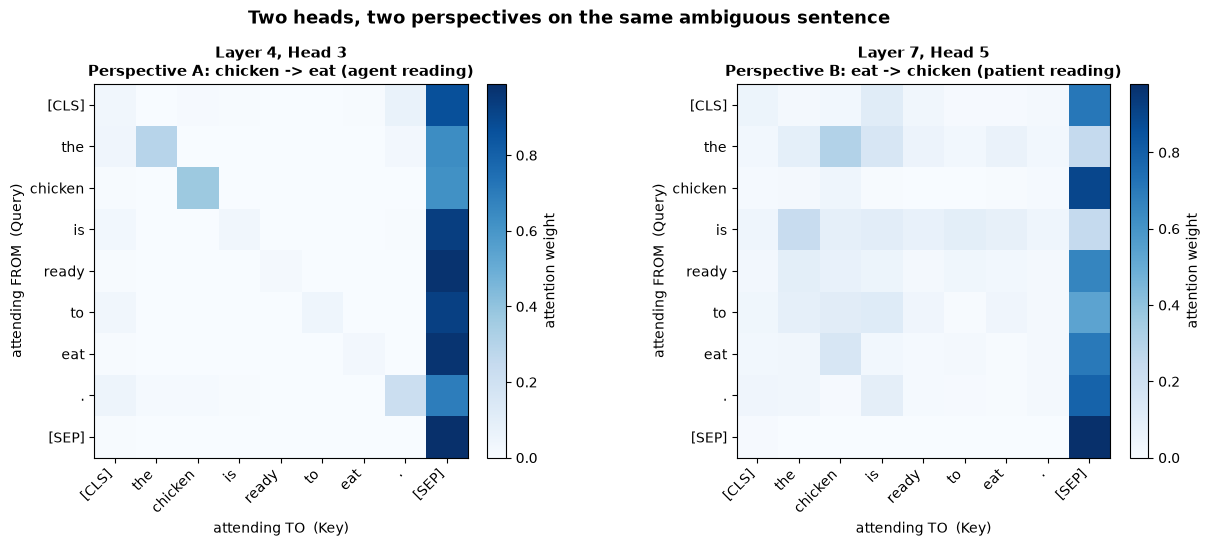

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Two (layer, head) pairs -- one per perspective on "chicken".
# Update these once Section 7 tells you which (layer, head) pairs score highest.
LAYER_A, HEAD_A = 4, 3   # Perspective A: chicken -> eat  (candidate "agent" reading)
LAYER_B, HEAD_B = 7, 5   # Perspective B: eat -> chicken  (candidate "patient" reading)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [
    (LAYER_A, HEAD_A, "Perspective A: chicken -> eat (agent reading)"),
    (LAYER_B, HEAD_B, "Perspective B: eat -> chicken (patient reading)"),
]

for ax, (LAYER, HEAD, label) in zip(axes, panels):
    A = attention[LAYER][0, HEAD].detach().numpy()   # [seq, seq] attention matrix
    im = ax.imshow(A, cmap='Blues', vmin=0, vmax=A.max())
    ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel("attending TO  (Key)", fontsize=10)
    ax.set_ylabel("attending FROM  (Query)", fontsize=10)
    ax.set_title(f"Layer {LAYER}, Head {HEAD}\n{label}", fontsize=11, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='attention weight')

fig.suptitle("Two heads, two perspectives on the same ambiguous sentence", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6b · All 12 heads of each perspective's layer, side by side

This pair of pictures is often the most convincing slide for students: **one layer, twelve heads, twelve different
attention patterns** — shown once for Perspective A's layer and once for Perspective B's layer, so you can point out
exactly which head within each layer carries the reading you're after.


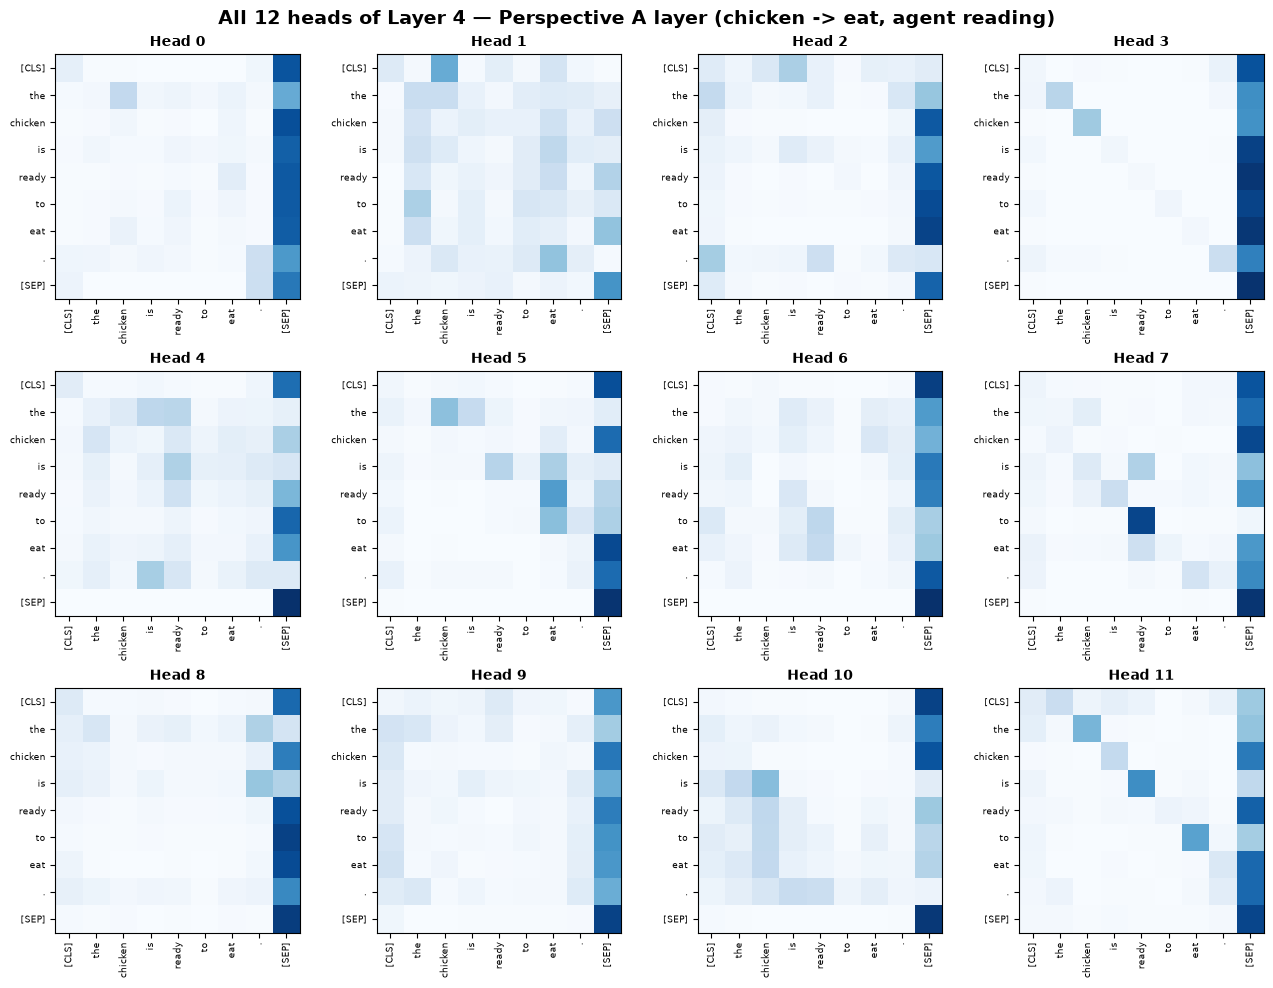

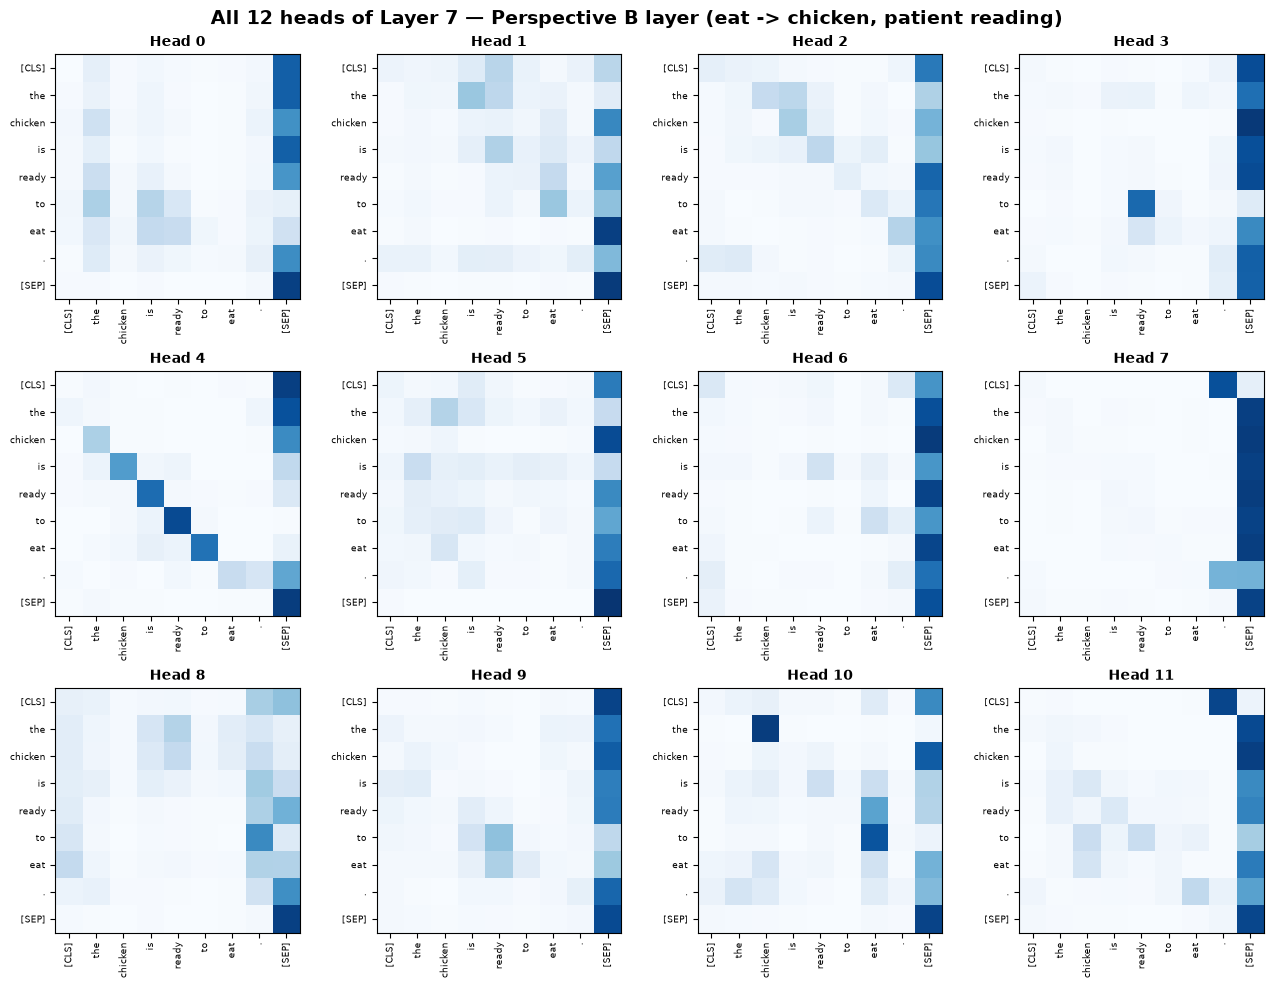

In [8]:
def plot_all_heads(LAYER, label):
    n_heads = attention[LAYER].shape[1]
    fig, axes = plt.subplots(3, 4, figsize=(13, 10))
    for h, ax in enumerate(axes.flat):
        A = attention[LAYER][0, h].detach().numpy()
        ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f"Head {h}", fontsize=10, fontweight='bold')
        ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=90, fontsize=6.5)
        ax.set_yticklabels(tokens, fontsize=6.5)
    fig.suptitle(f"All {n_heads} heads of Layer {LAYER} — {label}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Perspective A's layer: hunt visually for the chicken -> eat (agent) head
plot_all_heads(LAYER_A, "Perspective A layer (chicken -> eat, agent reading)")

# Perspective B's layer: hunt visually for the eat -> chicken (patient) head
plot_all_heads(LAYER_B, "Perspective B layer (eat -> chicken, patient reading)")


## 7 · Bonus — let the numbers find the heads for us

Hunting through 144 heads by eye is fun in class, but we can also **prove the point quantitatively**. The code below
scans **every layer and every head** and reports, for our two-word ambiguity:

* the head where **`chicken` attends most strongly to `eat`** &nbsp;(Perspective A — the *"chicken is ready to eat [something]"* / agent reading), and
* the head where **`eat` attends most strongly back to `chicken`** &nbsp;(Perspective B — the *"chicken is ready [for us] to eat [it]"* / patient reading).

If these turn out to be **different (layer, head) pairs**, you have just shown — with hard numbers — that the model
represents the two perspectives in **separate heads**, exactly as the theory predicts. The cell also copies the
winning numbers into `LAYER_A/HEAD_A` and `LAYER_B/HEAD_B` so you can re-run Sections 5 and 6 with them.


In [9]:
import numpy as np

def find_token_index(tokens, word):
    # Return the index of `word` in the token list (handles sub-word splits)
    word = word.lower()
    for i, t in enumerate(tokens):
        if t.replace('##', '') == word:
            return i
    for i, t in enumerate(tokens):              # fallback: first sub-word piece
        if word.startswith(t.replace('##', '')) and len(t.replace('##','')) >= 3:
            return i
    raise ValueError(f"'{word}' not found in {tokens}")

i_chicken = find_token_index(tokens, 'chicken')
i_eat     = find_token_index(tokens, 'eat')

# Perspective A: chicken -> eat   (candidate "agent" reading  -- chicken does the eating)
# Perspective B: eat -> chicken   (candidate "patient" reading -- chicken gets eaten)
best_A = (-1.0, None, None)   # (score, layer, head)
best_B = (-1.0, None, None)

for L in range(len(attention)):
    A = attention[L][0]                          # [heads, seq, seq]
    for H in range(A.shape[0]):
        s_A = A[H, i_chicken, i_eat].item()      # attention FROM chicken TO eat
        s_B = A[H, i_eat, i_chicken].item()      # attention FROM eat TO chicken
        if s_A > best_A[0]: best_A = (s_A, L, H)
        if s_B > best_B[0]: best_B = (s_B, L, H)

print("Perspective A -- strongest 'chicken -> eat' link:  "
      f"Layer {best_A[1]}, Head {best_A[2]}  (weight {best_A[0]:.2f})")
print("Perspective B -- strongest 'eat -> chicken' link:  "
      f"Layer {best_B[1]}, Head {best_B[2]}  (weight {best_B[0]:.2f})")
print()
if (best_A[1], best_A[2]) != (best_B[1], best_B[2]):
    print("Different heads dominate each direction -- multi-head attention in action!")
else:
    print("Same head dominated both directions this time -- try other layers, or eyeball Section 3/4.")

# Feed these numbers back into LAYER_A/HEAD_A and LAYER_B/HEAD_B in Sections 5 & 6
# (re-run those cells afterwards) to see the model's actual strongest heads.
LAYER_A, HEAD_A = best_A[1], best_A[2]
LAYER_B, HEAD_B = best_B[1], best_B[2]
print(f"\nLAYER_A, HEAD_A = {LAYER_A}, {HEAD_A}")
print(f"LAYER_B, HEAD_B = {LAYER_B}, {HEAD_B}")


Perspective A -- strongest 'chicken -> eat' link:  Layer 3, Head 8  (weight 0.68)
Perspective B -- strongest 'eat -> chicken' link:  Layer 2, Head 10  (weight 0.67)

Different heads dominate each direction -- multi-head attention in action!

LAYER_A, HEAD_A = 3, 8
LAYER_B, HEAD_B = 2, 10


## 8 · Teaching script — what to say while you click

1. **Set up the ambiguity first** (do this *before* showing the model). Read the sentence aloud and ask the class:
   *"Is the chicken about to eat, or about to be eaten?"* Let them argue — this classic "tough-construction" genuinely
   supports both readings.
2. **Open the Head View (Section 3).** *"BERT doesn't pick one meaning and throw the other away. It keeps several
   views of the sentence at the same time — one per head."*
3. **Find the two heads** (by eye, or using Section 7's numbers). *"Look — this head ties* chicken *to* eat *(chicken
   as the one eating). This other head ties* eat *back to* chicken *(chicken as the thing being eaten). Both readings
   are alive inside the model simultaneously."*
4. **Zoom out to the Model View (Section 4).** *"Twelve layers, twelve heads each — 144 different lenses on one short
   sentence. That parallel richness is what makes Transformers so strong at language."*
5. **Drop into the Neuron View (Section 5), once per perspective.** *"And here's the engine: every line you saw is
   just a Query vector dot-producted with a Key vector — the* softmax(QKᵀ/√dₖ) *from our formula, made visible. Watch
   how the Query lines up differently for each perspective."*
6. **Close with the two side-by-side heatmaps (Section 6).** *"Same model, same two words, two different heads, two
   different stories — that's multi-head attention captured on one slide."*

---
### Troubleshooting
| Problem | Fix |
|---------|-----|
| Views show blank / nothing renders | You're likely in VS Code or a plain `.py` run — use the `html_action='return'` + `display(...)` lines included in each cell, or just use the **Section 6** matplotlib heatmaps. |
| `OSError` / can't download model | First run needs internet to fetch `bert-base-uncased` from Hugging Face. Check your connection / proxy, then re-run. |
| Neuron View errors but Head View works | A `transformers` version mismatch with BertViz's internal wrappers. Re-install with the pinned versions shown in the comment in **Section 1**. |
| A word isn't found in Section 7 | BERT may have split it into sub-words; `print(tokens)` to see the exact pieces, then use one of those. |
| Section 6 heatmaps look identical | Re-run Section 6 **after** Section 7 so `LAYER_A/HEAD_A/LAYER_B/HEAD_B` hold the model's actual strongest heads, not the placeholder defaults. |

*End of notebook — pair this with the **Self-Attention &amp; Multi-Head Attention** PDF for the full theory-plus-practice lesson.*
